In [2]:
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
def fillna(df):
    df['분야'].fillna('None')
    df['직원 수'].fillna(df['직원 수'].median(), inplace = True)
    df['고객수(백만명)'].fillna(df['고객수(백만명)'].median(), inplace= True)
    df['기업가치(백억원)'].fillna('0000').astype(str)
    return df 
def change(df):
    df['기업가치(백억원)'] = df['기업가치(백억원)'].str.extract(r'(\d{1,4})')[0].fillna('0').astype(int)
    return df
def drop(df):
    df.drop('ID', axis = 1, inplace = True)
    return df
def format_features(df):
    features = ['국가', '분야', '투자단계', '인수여부', '상장여부', '기업가치(백억원)']
    for feature in features:
        le = LabelEncoder()
        le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df


In [3]:
import pandas as pd
train= pd.read_csv('company_train.csv')
test = pd.read_csv('company_test.csv')

In [4]:
def transform_features(df):
    df = fillna(df)
    df = change(df)
    df = drop(df)
    df = format_features(df)
    return df



In [5]:
train =transform_features(train)
test = transform_features(test)

C:\Users\sjune\AppData\Local\Temp\ipykernel_20968\306107799.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['직원 수'].fillna(df['직원 수'].median(), inplace = True)
C:\Users\sjune\AppData\Local\Temp\ipykernel_20968\306107799.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [6]:
train.isna().sum()

설립연도              0
국가                0
분야                0
투자단계              0
직원 수              0
인수여부              0
상장여부              0
고객수(백만명)          0
총 투자금(억원)         0
연매출(억원)           0
SNS 팔로워 수(백만명)    0
기업가치(백억원)         0
성공확률              0
dtype: int64

In [7]:
test.isna().sum()

설립연도              0
국가                0
분야                0
투자단계              0
직원 수              0
인수여부              0
상장여부              0
고객수(백만명)          0
총 투자금(억원)         0
연매출(억원)           0
SNS 팔로워 수(백만명)    0
기업가치(백억원)         0
dtype: int64

In [8]:
train.head()

,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률
0,2009,4,6,2,4126.0,0,0,56.0,3365.0,4764.0,4.71,0,0.3
1,2023,5,8,1,4167.0,1,0,80.0,4069.0,279.0,1.00,2,0.8
2,2018,6,2,2,3132.0,1,1,54.0,6453.0,12141.0,4.00,3,0.5
3,2016,5,10,1,3245.0,1,1,49.0,665.0,10547.0,2.97,0,0.7
4,2020,1,5,1,1969.0,0,1,94.0,829.0,9810.0,1.00,1,0.1


In [9]:
y = train['성공확률']

In [10]:
from sklearn.model_selection import train_test_split
X = train.drop('성공확률', axis = 1)
(X_train, X_val, y_train, y_val) = train_test_split(X, y, test_size = 0.2, random_state = 156)

In [11]:
X_test = test

In [12]:
#전처리 필요없는 트리 기반 학습 

In [13]:
#1.decision Tree 학습 
from sklearn.tree import DecisionTreeRegressor
dt_clf = DecisionTreeRegressor(max_depth = 4, min_samples_split = 16, random_state = 156)
dt_clf.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, min_samples_split=16, random_state=156)

In [14]:
from sklearn.tree import export_graphviz

export_graphviz(dt_clf, out_file="tree.dot", class_names = ['Not Transported', 'Transported'], feature_names= X_train.columns.tolist(), impurity = True, filled = True)

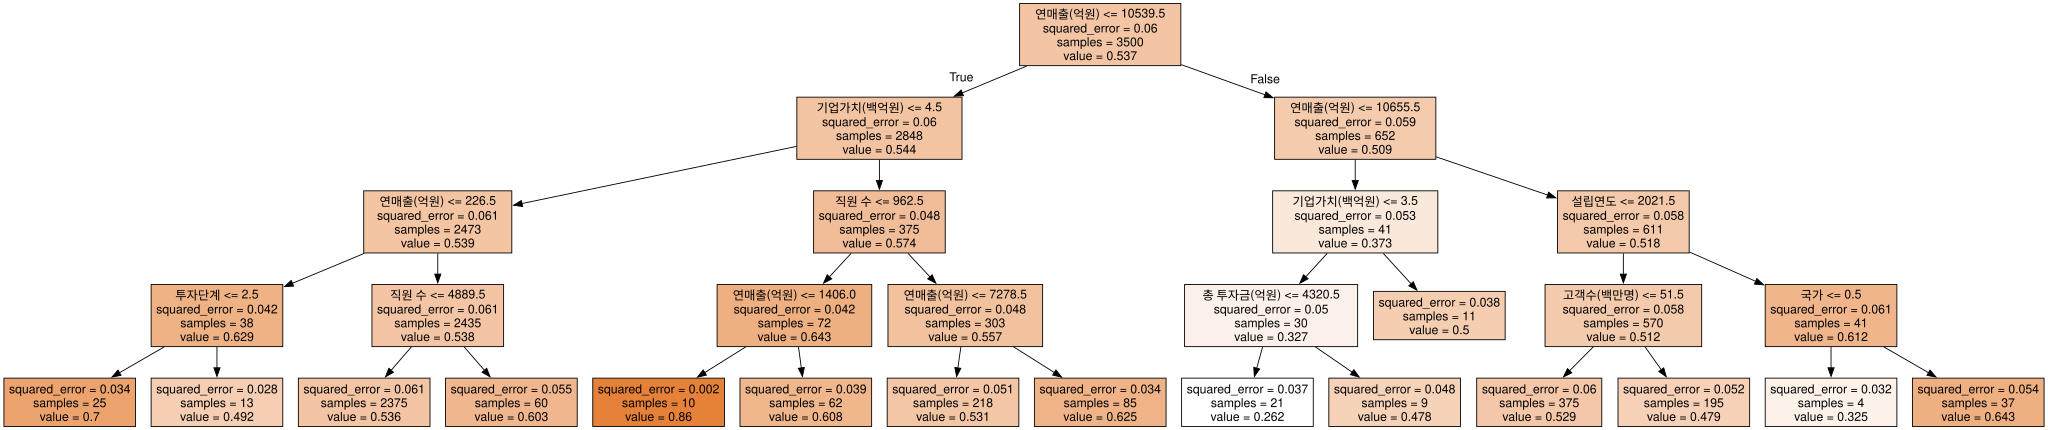

In [15]:
import  graphviz
with open("tree.dot",encoding='utf-8') as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [16]:
from PIL import Image
from graphviz import Source
import io
graph = Source(dot_graph)
# graph: Graphviz Source 객체라고 가정
png_bytes = graph.pipe(format='png')  # 이미지 바이너리 얻기

# BytesIO로 이미지로 열기
image = Image.open(io.BytesIO(png_bytes))

# 이미지 파일로 저장
image.save("tree_company.png")

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
pred = dt_clf.predict(X_val)
mse = mean_squared_error(y_val, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, pred)
r2 = r2_score(y_val, pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.1973
MSE: 0.0551
RMSE: 0.2347
R² Score: -0.0339


In [18]:
#R2 score 가 음수 이를 해결하기 위해 max_depth 개선 시도 


In [19]:
from sklearn.model_selection import GridSearchCV
params = {
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_samples_split": [16, 20, 22],
}
grid_cv = GridSearchCV(dt_clf, param_grid = params, scoring = "neg_mean_squared_error", cv = 5, verbose = 1)
grid_cv.fit(X_train, y_train)
print('GridSearchCV 최고 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
GridSearchCV 최고 정확도 수치: -0.0604
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 3, 'min_samples_split': 16}


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
best_df_clf = grid_cv.best_estimator_
pred = best_df_clf.predict(X_val)
mse = mean_squared_error(y_val, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, pred)
r2 = r2_score(y_val, pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.1957
MSE: 0.0544
RMSE: 0.2332
R² Score: -0.0209


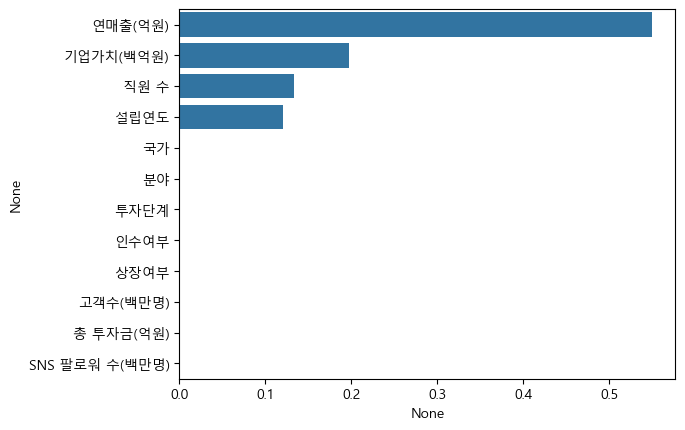

In [21]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로 찾기 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 또는 'NanumGothic', 'AppleGothic' (Mac)
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 부호 깨짐 방지
import seaborn as sns 
import matplotlib.pyplot as plt
ftr_importance_values = best_df_clf.feature_importances_
ftr_importances = pd.Series(ftr_importance_values, index = X_train.columns)

#중요도 순으로 Series 정렬 
ftr_top20 = ftr_importances.sort_values(ascending = False)[:20]
sns.barplot(x = ftr_top20, y = ftr_top20.index)
plt.show()

In [22]:
from sklearn.tree import export_graphviz

export_graphviz(best_df_clf, out_file="tree.dot1", feature_names= X_train.columns.tolist(), impurity = True, filled = True)

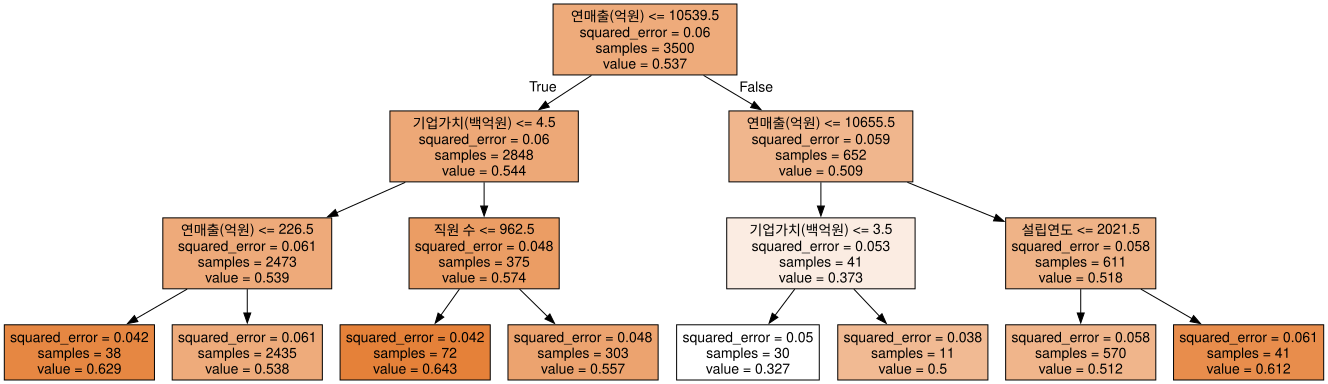

In [23]:
import  graphviz
with open("tree.dot1",encoding='utf-8') as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

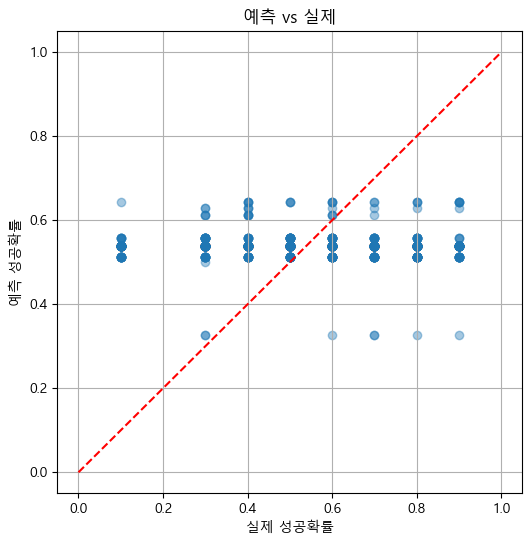

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val, pred, alpha=0.4)
plt.plot([0,1], [0,1], 'r--')  # 완벽한 예측선
plt.xlabel("실제 성공확률")
plt.ylabel("예측 성공확률")
plt.title("예측 vs 실제")
plt.grid(True)
plt.show()

In [25]:
##트리 기반 학습을 어떻게 개선... random forest, XGB, LightGBM 
## Regressor
### knn학습 

In [26]:
from sklearn.ensemble import RandomForestRegressor 
rf = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_split=10, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
mse = mean_squared_error(y_val, pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, pred_rf)
r2 = r2_score(y_val, pred_rf)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.1936
MSE: 0.0535
RMSE: 0.2312
R² Score: -0.0037


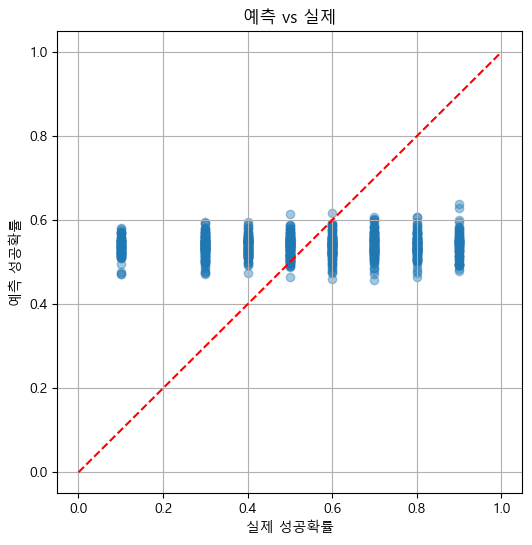

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val, pred_rf, alpha=0.4)
plt.plot([0,1], [0,1], 'r--')  # 완벽한 예측선
plt.xlabel("실제 성공확률")
plt.ylabel("예측 성공확률")
plt.title("예측 vs 실제")
plt.grid(True)
plt.show()

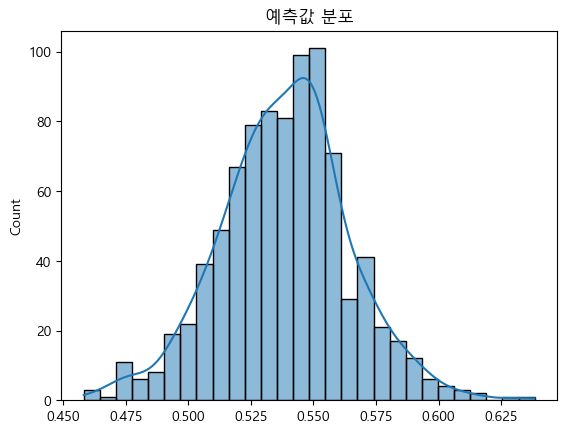

In [29]:
import seaborn as sns
sns.histplot(pred_rf, kde=True)
plt.title("예측값 분포")
plt.show()

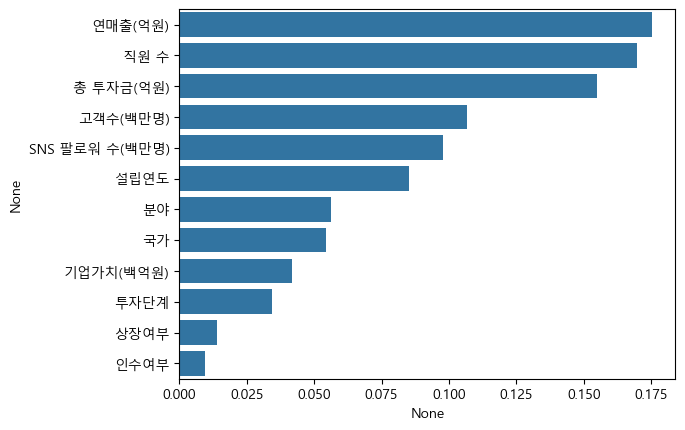

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline 
ftr_importance_values = rf.feature_importances_
ftr_importances = pd.Series(ftr_importance_values, index = X_train.columns)

#중요도 순으로 Series 정렬 
ftr_top20 = ftr_importances.sort_values(ascending = False)[:20]
sns.barplot(x = ftr_top20, y = ftr_top20.index)
plt.show()

In [34]:
#평균값만 출력하고 있음.... 
# XGB, LightGBM 
import xgboost as xgb
from xgboost import XGBRegressor
from xgboost import plot_importance
import warnings 
warnings.filterwarnings('ignore')
print(X_train.shape, X_val.shape, X_test.shape)

(3500, 12) (876, 12) (1755, 12)


In [35]:
dtr = xgb.DMatrix(data = X_train, label = y_train)
dval = xgb.DMatrix(data = X_val, label = y_val)


In [57]:
params = {'max_depth':3,
          'eta':0.05,
          'objective':'reg:squarederror',
          'eval_metric':'rmse'
         }
num_rounds = 400

In [58]:
eval_list = [(dtr,'train'),(dval,'eval')]
xgb_model = xgb.train(params = params, dtrain = dtr, num_boost_round = num_rounds, early_stopping_rounds = 50, evals = eval_list)

[0]	train-rmse:0.24416	eval-rmse:0.23076
[1]	train-rmse:0.24401	eval-rmse:0.23081
[2]	train-rmse:0.24387	eval-rmse:0.23085
[3]	train-rmse:0.24374	eval-rmse:0.23082
[4]	train-rmse:0.24361	eval-rmse:0.23086
[5]	train-rmse:0.24341	eval-rmse:0.23095
[6]	train-rmse:0.24323	eval-rmse:0.23102
[7]	train-rmse:0.24311	eval-rmse:0.23103
[8]	train-rmse:0.24293	eval-rmse:0.23109
[9]	train-rmse:0.24282	eval-rmse:0.23113
[10]	train-rmse:0.24267	eval-rmse:0.23113
[11]	train-rmse:0.24256	eval-rmse:0.23116
[12]	train-rmse:0.24240	eval-rmse:0.23124
[13]	train-rmse:0.24229	eval-rmse:0.23127
[14]	train-rmse:0.24215	eval-rmse:0.23128
[15]	train-rmse:0.24201	eval-rmse:0.23127
[16]	train-rmse:0.24191	eval-rmse:0.23133
[17]	train-rmse:0.24178	eval-rmse:0.23132
[18]	train-rmse:0.24169	eval-rmse:0.23139
[19]	train-rmse:0.24154	eval-rmse:0.23145
[20]	train-rmse:0.24141	eval-rmse:0.23139
[21]	train-rmse:0.24126	eval-rmse:0.23139
[22]	train-rmse:0.24116	eval-rmse:0.23139
[23]	train-rmse:0.24107	eval-rmse:0.23142
[2

In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
pred1= xgb_model.predict(dval)
mse = mean_squared_error(y_val, pred1)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, pred1)
r2 = r2_score(y_val, pred1)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.1944
MSE: 0.0536
RMSE: 0.2316
R² Score: -0.0070


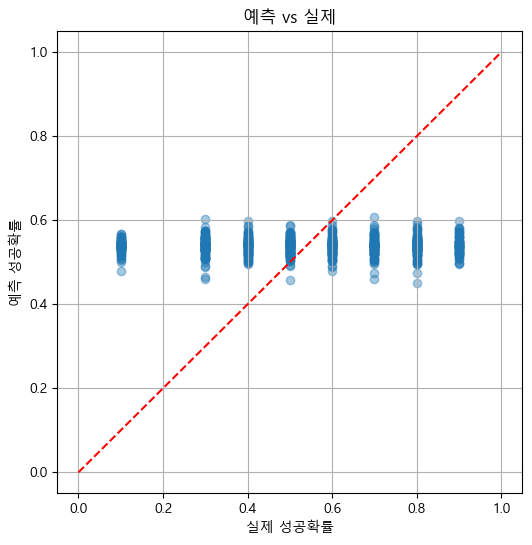

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val, pred1, alpha=0.4)
plt.plot([0,1], [0,1], 'r--')  # 완벽한 예측선
plt.xlabel("실제 성공확률")
plt.ylabel("예측 성공확률")
plt.title("예측 vs 실제")
plt.grid(True)
plt.show()

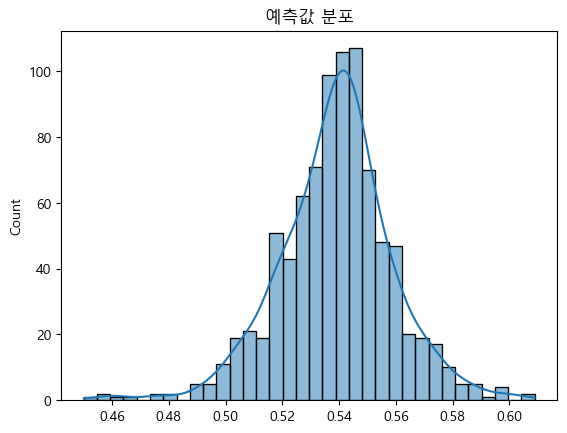

In [61]:
import seaborn as sns
sns.histplot(pred1, kde=True)
plt.title("예측값 분포")
plt.show()

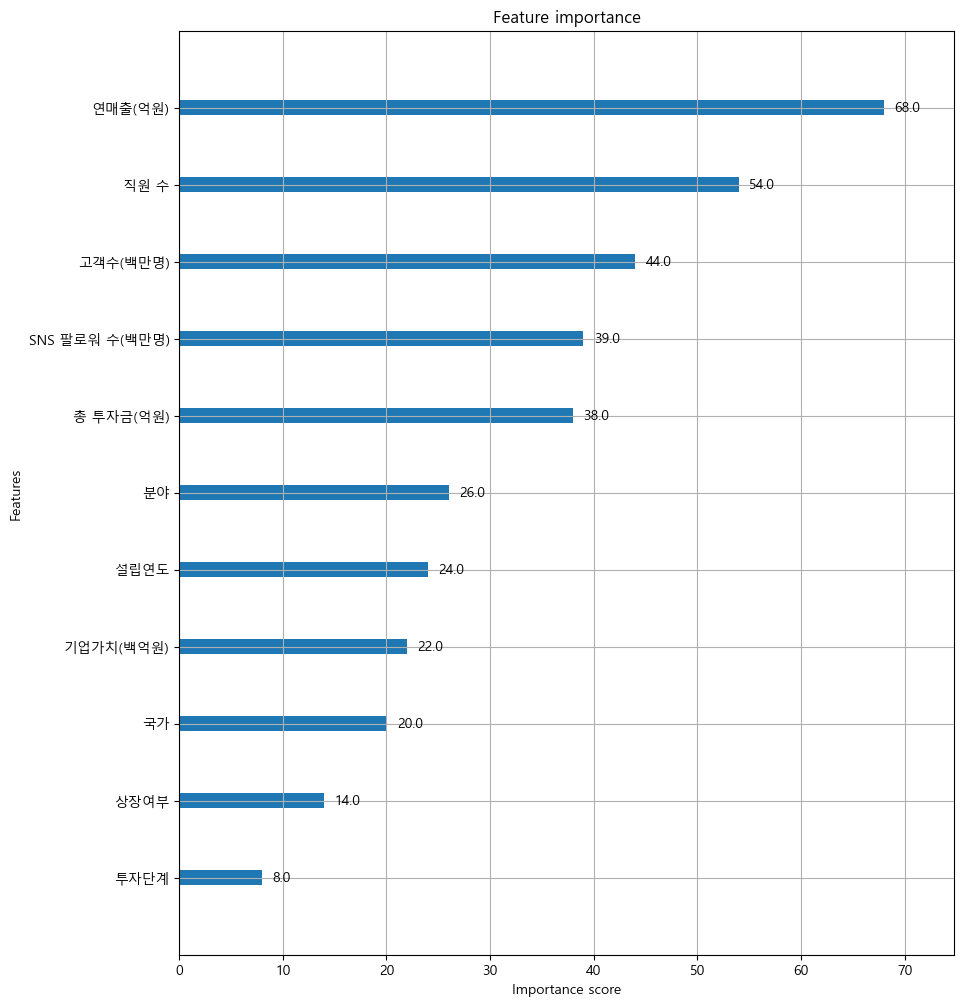

In [66]:
import matplotlib.pyplot as plt
%matplotlib inline 
fig, ax = plt.subplots(figsize = (10, 12))
plot_importance(xgb_model, ax = ax)
plt.show()

In [79]:
from hyperopt import hp
xgb_search_space = {'max_depth':hp.quniform('max_depth',5,20,1),
                    'min_child_weight':hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate':hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree':hp.uniform('colsample_bytree', 0.5, 1),
                    'n_estimators':hp.quniform('n_estimators', 100, 500, 50),
                    'sub_sample':hp.uniform('subsample',0.5, 1.0),
                   }

In [87]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from hyperopt import STATUS_OK
def objective_func(search_space):
    xgb_model = XGBRegressor(max_depth = int(search_space['max_depth']),
                             min_child_weight = int(search_space['min_child_weight']),
                             learning_rate = search_space['learning_rate'],
                             colsample_bytree = search_space['colsample_bytree'],
                             n_estimators = int(search_space['n_estimators']),
                             sub_sample = search_space['sub_sample'],
                             eval_metric = 'logloss')
    scores = cross_val_score(xgb_model, X_train, y_train, scoring='neg_root_mean_squared_error', cv=3)
    return{'loss':-1*np.mean(scores), 'status': STATUS_OK}
    
    
                             
                             

In [88]:
from hyperopt import fmin, tpe, Trials
trial_val = Trials()
best = fmin(fn = objective_func, 
            space = xgb_search_space, 
            algo = tpe.suggest, 
            max_evals = 50, 
            trials = trial_val, rstate = np.random.default_rng(seed = 9))
print('best:', best)

100%|███████████████████████████████████████████████| 50/50 [07:52<00:00,  9.46s/trial, best loss: 0.24363544100097503]
best: {'colsample_bytree': 0.5728762507964956, 'learning_rate': 0.010341257624109533, 'max_depth': 14.0, 'min_child_weight': 1.0, 'n_estimators': 400.0, 'subsample': 0.5266579559840265}


In [90]:
dtr = xgb.DMatrix(data = X_train, label = y_train)
dval = xgb.DMatrix(data = X_val, label = y_val)

params = {'max_depth':int(best['max_depth']),
          'min_child_weight':int(best['min_child_weight']),
          'learning_rate':round(best['learning_rate'],5),
          'colsample_bytree':round(best['colsample_bytree'],5),
          'n_estimators':int(best['n_estimators']),
          'sub_sample':round(best['subsample'],5),
          'objective':'reg:squarederror',
          'eval_metric':'logloss'
         }
num_rounds = 400
eval_list = [(dtr,'train'),(dval,'eval')]
xgb_model = xgb.train(params = params, dtrain = dtr, num_boost_round = num_rounds, early_stopping_rounds = 50, evals = eval_list)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
pred1= xgb_model.predict(dval)
mse = mean_squared_error(y_val, pred1)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, pred1)
r2 = r2_score(y_val, pred1)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

[0]	train-logloss:0.68912	eval-logloss:0.69042
[1]	train-logloss:0.68821	eval-logloss:0.69039
[2]	train-logloss:0.68716	eval-logloss:0.69035
[3]	train-logloss:0.68617	eval-logloss:0.69036
[4]	train-logloss:0.68517	eval-logloss:0.69030
[5]	train-logloss:0.68415	eval-logloss:0.69028
[6]	train-logloss:0.68323	eval-logloss:0.69027
[7]	train-logloss:0.68203	eval-logloss:0.69032
[8]	train-logloss:0.68096	eval-logloss:0.69025
[9]	train-logloss:0.68011	eval-logloss:0.69025
[10]	train-logloss:0.67934	eval-logloss:0.69023
[11]	train-logloss:0.67831	eval-logloss:0.69018
[12]	train-logloss:0.67734	eval-logloss:0.69018
[13]	train-logloss:0.67631	eval-logloss:0.69010
[14]	train-logloss:0.67524	eval-logloss:0.69005
[15]	train-logloss:0.67451	eval-logloss:0.69000
[16]	train-logloss:0.67342	eval-logloss:0.68997
[17]	train-logloss:0.67250	eval-logloss:0.68998
[18]	train-logloss:0.67161	eval-logloss:0.68997
[19]	train-logloss:0.67062	eval-logloss:0.68996
[20]	train-logloss:0.66973	eval-logloss:0.68995
[2

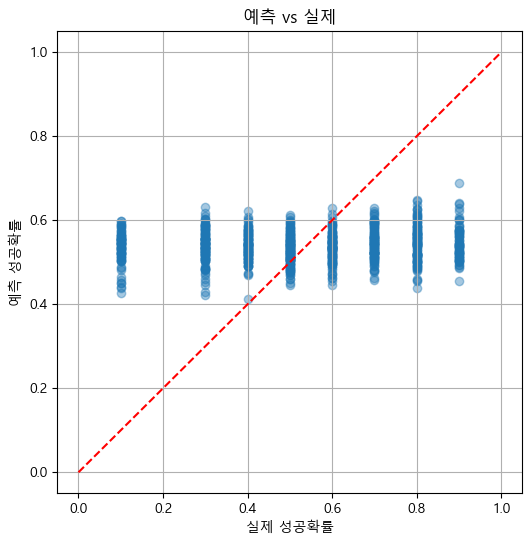

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val, pred1, alpha=0.4)
plt.plot([0,1], [0,1], 'r--')  # 완벽한 예측선
plt.xlabel("실제 성공확률")
plt.ylabel("예측 성공확률")
plt.title("예측 vs 실제")
plt.grid(True)
plt.show()

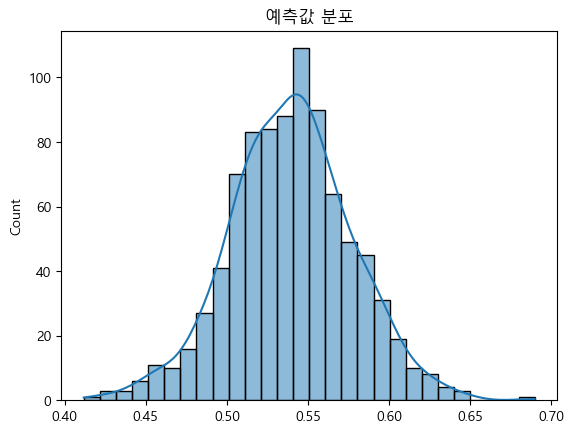

In [92]:
import seaborn as sns
sns.histplot(pred1, kde=True)
plt.title("예측값 분포")
plt.show()

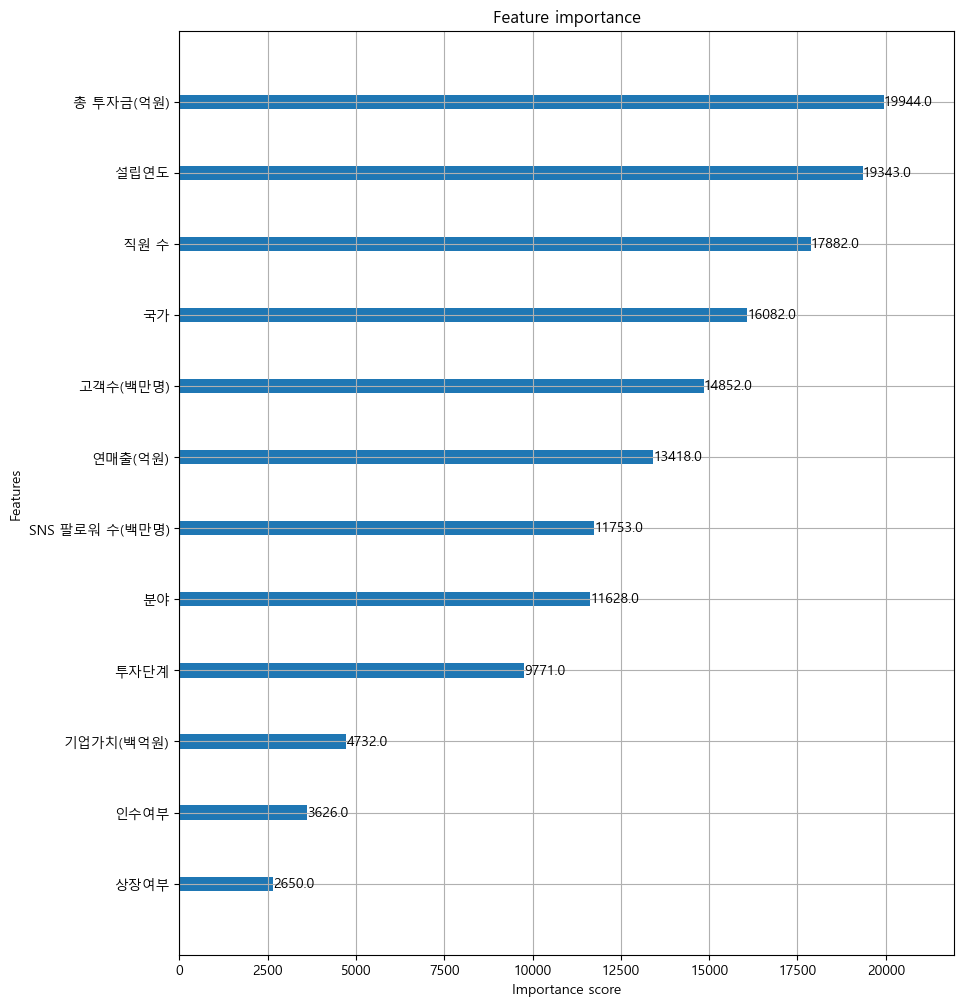

In [93]:
import matplotlib.pyplot as plt
%matplotlib inline 
fig, ax = plt.subplots(figsize = (10, 12))
plot_importance(xgb_model, ax = ax)
plt.show()

In [95]:
from hyperopt import hp
xgb_search_space = {'max_depth':hp.quniform('max_depth',10,25,1),
                    'min_child_weight':hp.quniform('min_child_weight', 1, 6, 1),
                    'learning_rate':hp.uniform('learning_rate', 0.005, 0.05),
                    'colsample_bytree':hp.uniform('colsample_bytree', 0.5, 0.9),
                    'n_estimators':hp.quniform('n_estimators', 300, 700, 50),
                    'subsample':hp.uniform('subsample',0.4, 0.7),
                    'gamma':hp.uniform('gamma',0, 5)
                   }

In [96]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from hyperopt import STATUS_OK
def objective_func(search_space):
    xgb_model = XGBRegressor(max_depth = int(search_space['max_depth']),
                             min_child_weight = int(search_space['min_child_weight']),
                             learning_rate = search_space['learning_rate'],
                             colsample_bytree = search_space['colsample_bytree'],
                             n_estimators = int(search_space['n_estimators']),
                             subsample = search_space['subsample'],
                             gamma = search_space['gamma'],
                             eval_metric = 'logloss')
    scores = cross_val_score(xgb_model, X_train, y_train, scoring='neg_root_mean_squared_error', cv=3)
    return{'loss':-1*np.mean(scores), 'status': STATUS_OK}
    
    
           

In [97]:
from hyperopt import fmin, tpe, Trials
trial_val = Trials()
best = fmin(fn = objective_func, 
            space = xgb_search_space, 
            algo = tpe.suggest, 
            max_evals = 100, 
            trials = trial_val, rstate = np.random.default_rng(seed = 9))
print('best:', best)

100%|█████████████████████████████████████████████| 100/100 [03:12<00:00,  1.93s/trial, best loss: 0.24442733399468572]
best: {'colsample_bytree': 0.829187291781227, 'gamma': 1.5585724165852166, 'learning_rate': 0.0465100183287186, 'max_depth': 18.0, 'min_child_weight': 5.0, 'n_estimators': 700.0, 'subsample': 0.43920015122212847}


In [98]:
dtr = xgb.DMatrix(data = X_train, label = y_train)
dval = xgb.DMatrix(data = X_val, label = y_val)

params = {'max_depth':int(best['max_depth']),
          'min_child_weight':int(best['min_child_weight']),
          'learning_rate':round(best['learning_rate'],5),
          'colsample_bytree':round(best['colsample_bytree'],5),
          'n_estimators':int(best['n_estimators']),
          'sub_sample':round(best['subsample'],5),
          'gamma':round(best['gamma'],5),
          'objective':'reg:squarederror',
          'eval_metric':'logloss'
         }
num_rounds = 400
eval_list = [(dtr,'train'),(dval,'eval')]
xgb_model = xgb.train(params = params, dtrain = dtr, num_boost_round = num_rounds, early_stopping_rounds = 50, evals = eval_list)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
pred1= xgb_model.predict(dval)
mse = mean_squared_error(y_val, pred1)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, pred1)
r2 = r2_score(y_val, pred1)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

[0]	train-logloss:0.69033	eval-logloss:0.69044
[1]	train-logloss:0.69033	eval-logloss:0.69044
[2]	train-logloss:0.69033	eval-logloss:0.69044
[3]	train-logloss:0.69033	eval-logloss:0.69044
[4]	train-logloss:0.69033	eval-logloss:0.69044
[5]	train-logloss:0.69033	eval-logloss:0.69044
[6]	train-logloss:0.69033	eval-logloss:0.69044
[7]	train-logloss:0.69033	eval-logloss:0.69044
[8]	train-logloss:0.69033	eval-logloss:0.69044
[9]	train-logloss:0.69033	eval-logloss:0.69044
[10]	train-logloss:0.69033	eval-logloss:0.69044
[11]	train-logloss:0.69033	eval-logloss:0.69044
[12]	train-logloss:0.69033	eval-logloss:0.69044
[13]	train-logloss:0.69033	eval-logloss:0.69044
[14]	train-logloss:0.69033	eval-logloss:0.69044
[15]	train-logloss:0.69033	eval-logloss:0.69044
[16]	train-logloss:0.69033	eval-logloss:0.69044
[17]	train-logloss:0.69033	eval-logloss:0.69044
[18]	train-logloss:0.69033	eval-logloss:0.69044
[19]	train-logloss:0.69033	eval-logloss:0.69044
[20]	train-logloss:0.69033	eval-logloss:0.69044
[2